[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/01_Basic_Sequencing_emu.ipynb)

# 01 - Basic Sequencing with tProc v2 (Emulator Edition)

**Objective:** Learn how to define pulses, create a sequence, acquire data, and understand the basic structure of a tProc v2 program -- running against the Verilator emulator instead of a physical RFSoC.

This is a 1:1 port of the on-hardware tutorial `01_Basic_Sequencing.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo). Only Section 1 (connecting to the board) is adapted; everything else -- program structure, pulse definitions, `_body()`, `acquire_decimated()` -- is unchanged, since `prog.acquire()`/`prog.acquire_decimated()` dispatch to hardware or emulator based on the `soc` object type. See [`00_Getting_Started_emu.ipynb`](./00_Getting_Started_emu.ipynb) if you haven't run that one yet.

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [1]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        # Fast path: a prebuilt Verilator 5.042, compiled on a real Colab
        # runtime and hosted as a GitHub Release asset -- avoids a ~10-15
        # minute source compile on every session. Falls back to building
        # from source if the download/extraction doesn't work out (e.g. the
        # asset is gone, or a future Colab image isn't binary-compatible).
        PREBUILT_URL = (
            "https://github.com/openquantumhardware/qick/releases/download/"
            "verilator-5.042-colab/verilator-5.042-colab-x86_64.tar.gz"
        )
        prebuilt_ok = False
        print("Trying prebuilt Verilator 5.042 (fast path) ...")
        try:
            run(f"curl -fL -o /tmp/verilator-prebuilt.tar.gz {PREBUILT_URL}")
            run("tar -C /usr/local -xzf /tmp/verilator-prebuilt.tar.gz")
            prebuilt_ok = "5.042" in verilator_version()
        except RuntimeError as e:
            print(f"Prebuilt Verilator download/install failed ({e}); building from source instead.")

        if prebuilt_ok:
            print("Prebuilt Verilator 5.042 installed.")
        else:
            print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
            print("Installing build dependencies (apt) ...")
            run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
            run(
                "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
                "git help2man perl python3 make autoconf g++ flex bison ccache "
                "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
            )

            os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
            run("autoconf")
            run("./configure")
            run("make -j$(nproc)")
            run("make install")
            os.chdir(REPO_DIR)
            final_version = verilator_version()
            if "5.042" not in final_version:
                raise RuntimeError(
                    "Verilator build finished but 'verilator --version' still doesn't "
                    f"report 5.042 (got: {final_version!r})"
                )
            print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


Not running in Colab -- skipping clone/build (using the local checkout as-is).


## 1. Setup

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

import qick
from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan

# Emulator entry point (drop-in replacement for QickSoc)
from qick_emu import QickEmu

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# --- No firmware .bit file or physical board needed ---
# On real hardware:
#     BITSTREAM_PATH = '/path/to/your/firmware.bit'
#     soc = QickSoc(BITSTREAM_PATH)
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# Define hardware channels (QICKEmu channel assignment, see 00_intro_emu.ipynb)
GEN_CH = 0
RO_CH  = 0

ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '01_basic_sequencing'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {ARTIFACTS_ROOT}')

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/01_basic_sequencing


## 2. Your First Program: The Structure

Every tProc v2 program follows this pattern:

In [3]:
class MyFirstProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        """Setup: Called once when the program is compiled."""
        # 1. Declare hardware resources
        # 2. Define envelopes and pulses
        # 3. Configure readout
        pass

    def _body(self, cfg):
        """Sequence: Called for each repetition (shot)."""
        # 1. Play pulses
        # 2. Trigger readout
        pass

The key distinction:
- **`_initialize()`** runs during **compilation** (Python side, once)
- **`_body()`** runs during **execution** (tProc side, many times) -- on the emulator, "execution" means the compiled sequence is replayed through the Verilator testbench.

## 3. A Simple Single-Pulse Program

Let's create a program that plays a single constant pulse and measures it.

[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/single_pulse ...


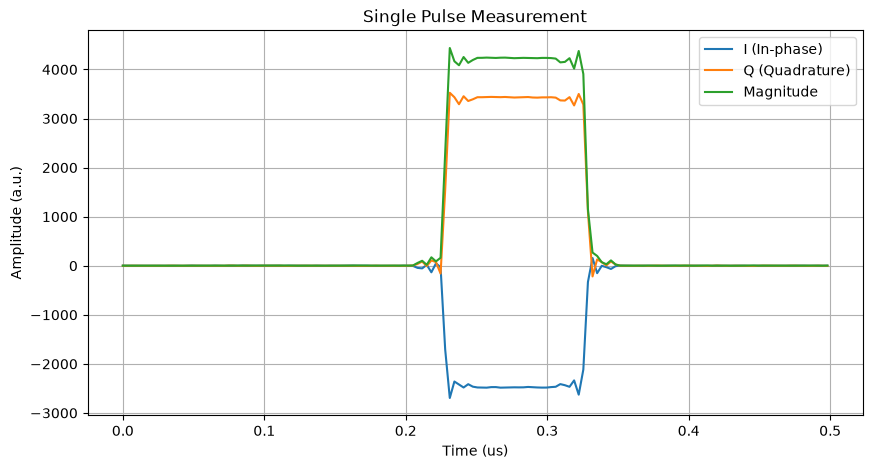

In [4]:
class SinglePulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        # Declare the generator and readout channels
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)  # nqz=1 means no frequency folding
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a constant pulse (no envelope shaping)
        self.add_pulse(
            ch=cfg['gen_ch'],
            name="my_pulse",
            style="const",           # Constant amplitude
            freq=cfg['freq'],        # Frequency in MHz
            length=cfg['pulse_len'], # Duration in microseconds
            phase=cfg['phase'],      # Phase in degrees
            gain=cfg['gain']         # Amplitude (0 to 1)
        )

        # Configure the readout
        self.add_readoutconfig(
            ch=cfg['ro_ch'],
            name="my_ro",
            freq=cfg['freq'],
            gen_ch=cfg['gen_ch']
        )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # Play the pulse at time t=0
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0)
        # Trigger the readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configure the experiment
config = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100.0,           # MHz -- QICKEmu range is narrower than ZCU216, see 00_intro_emu.ipynb
    'pulse_len': 0.1,       # microseconds
    'phase': 0,             # degrees
    'gain': 1.0,            # full amplitude
    'trig_time': 0.2,       # microseconds (when to start readout)
    'ro_len': 0.5           # microseconds (readout duration)
}

# Create and run the program
prog = SinglePulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'single_pulse'
OUT.mkdir(parents=True, exist_ok=True)

# First simulation of the kernel session: build=True runs `make verilate`.
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used from here on.
soc = soc.prepare_emu(memdir=OUT, build=True)

# Acquire data (decimated mode gives IQ traces vs time)
iq_data = prog.acquire_decimated(soc, rounds=10)  # 10 averages
time_axis = prog.get_time_axis(ro_index=0)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(time_axis, iq_data[0][:,0], label='I (In-phase)')
plt.plot(time_axis, iq_data[0][:,1], label='Q (Quadrature)')
plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Single Pulse Measurement')
plt.grid(True)
plt.show()

**Explanation of the cell:**
- `declare_gen()` and `declare_readout()` tell the tProc which hardware resources we'll use
- `add_pulse()` defines a pulse with its parameters. A constant pulse (`style="const"`) has flat amplitude.
- In `_body()`, `pulse()` schedules the pulse, and `trigger()` starts the readout acquisition
- `acquire_decimated()` records the program as AXI transactions, runs the Verilator testbench, and returns averaged IQ data. The `rounds` parameter controls how many times the whole simulation is repeated for averaging.

## 4. Multiple Pulses in One Sequence

You can define many pulses in `_initialize()` and play them in any order.

[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/01_basic_sequencing/multi_pulse ...


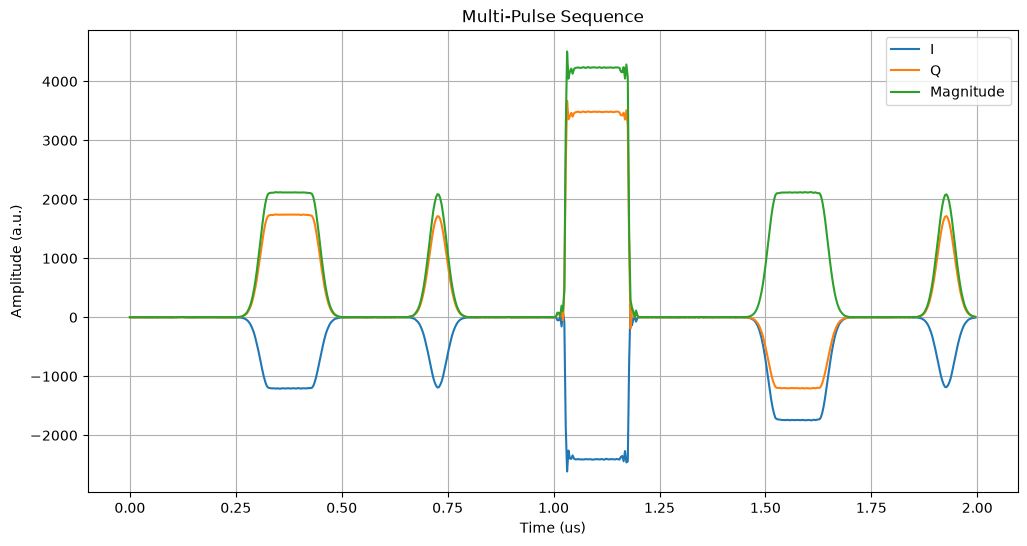

In [5]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a Gaussian envelope
        ramp_len = 0.2
        self.add_gauss(
            ch=cfg['gen_ch'],
            name="gauss_env",
            sigma=ramp_len/10,
            length=ramp_len,
            even_length=True
        )

        # Define different pulse types
        # Flat-top pulse (Gaussian rise/fall, constant middle)
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_flattop",
            style="flat_top", envelope="gauss_env",
            freq=cfg['freq'], length=0.1, phase=0, gain=1.0
        )

        # Gaussian pulse
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_gauss",
            style="arb", envelope="gauss_env",
            freq=cfg['freq'], phase=0, gain=1.0
        )

        # Constant pulse
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_const",
            style="const",
            freq=cfg['freq'], length=0.15, phase=0, gain=1.0
        )

        # Flat-top pulse with 90-degree phase
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_flattop_90",
            style="flat_top", envelope="gauss_env",
            freq=cfg['freq'], length=0.1, phase=90, gain=1.0
        )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro", freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator (the TB does not
        # instantiate the DDR4 buffer IP) -- kept so this program matches
        # the on-hardware version byte-for-byte.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        # Sequence of pulses at different times (microseconds)
        self.pulse(ch=cfg['gen_ch'], name="p_flattop", t=0)
        self.pulse(ch=cfg['gen_ch'], name="p_gauss", t=0.4)
        self.pulse(ch=cfg['gen_ch'], name="p_const", t=0.8)
        self.pulse(ch=cfg['gen_ch'], name="p_flattop_90", t=1.2)
        self.pulse(ch=cfg['gen_ch'], name="p_gauss", t=1.6)

# Run the multi-pulse sequence
config['ro_len'] = 2.0  # Longer readout to capture all pulses
prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'multi_pulse'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)  # reuse the binary built above

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(12, 6))
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Multi-Pulse Sequence')
plt.grid(True)
plt.show()

**Key observations from this example:**
- Once a pulse is defined, it can be reused multiple times (`p_gauss` appears twice)
- Different pulse styles serve different purposes: `const` for square pulses, `arb` for shaped pulses, `flat_top` for shaped pulses with a constant top
- The `even_length=True` parameter ensures the envelope has an even number of samples, which is required for some operations

## 5. Inspecting Your Program

You can print the program to see what the tProc will execute -- this works identically on hardware and emulator, since it only inspects the compiled program, not `soc`:

In [6]:
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='my_ro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x78e7573f03e0>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x78e7573f3860>}, t_regs={'t': 430})
	OpenLoop(n=1, name='reps')
	Trigger(ros=[0], tts=[], pins=[0], t=0.2, width=0.023251488095238096, ddr4=True, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x78e75745dee0>, 'width': <qick.asm_v2.QickParam object at 0x78e7573f1370>}, t_regs={'t': 86, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 10})
	Pulse(ch=0, name='p_flattop', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x78e7573f19a0>}, t_regs={'t': 0})
	Pulse(ch=0, name='p_gauss', t=0.4, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x78e7573f2570>}, t_regs={'t': 172})
	Pulse(ch=0, name='p_const', t=0.8, tag=None, t_params={'t': <qick.asm_v2.QickPar

**Explanation:** This prints the compiled program in three sections:
1. **macros:** High-level operations (pulse definitions, loops, triggers)
2. **registers:** Allocated data registers
3. **pulses:** Defined waveforms with their parameters
4. **expanded ASM:** The actual assembly code that runs on the tProc

Understanding this output becomes important when debugging complex sequences.

## 6. Summary

You have learned:
- The structure of a tProc v2 program (`_initialize` vs `_body`)
- How to define and play pulses of different styles (const, arb, flat_top)
- How to trigger readout and acquire IQ data through the emulator
- How to inspect the generated assembly code

**Next steps:** Proceed to [`02_Parameter_Sweeps_emu.ipynb`](./02_Parameter_Sweeps_emu.ipynb) to learn how to automate parameter variation and create 2D scans.